In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
Z = 82
E = 10*1000 # MeV
t_edges = np.arange(0, 30, 0.2) # in units of X0

from calo_flash import shoot
results = shoot(E, Z, t_edges)

In [4]:
### add stuff
results['log_Ep1'] = np.log(results['E'] + 1)
results['x'] = results['r'] * np.cos(results['phi'])
results['y'] = results['r'] * np.sin(results['phi'])

In [5]:
### plot point cloud on cylindrical coordinates using plotly
import plotly.express as px
import pandas as pd
N = 10000
subset_indices = np.random.choice(len(results['E']), size=N, replace=False)
subset_results = {k: v[subset_indices] for k, v in results.items()}
df = pd.DataFrame(subset_results)
fig = px.scatter_3d(df, x='x', y='y', z='t', color='E', size='log_Ep1', size_max=5)
fig.update_traces(marker=dict(line=dict(width=0)))
max_range = 20.0
fig.update_layout(
    width=1000,
    height=800,
    scene=dict(
        xaxis=dict(range=[-max_range, max_range]),
        yaxis=dict(range=[-max_range, max_range]),
    )
)
fig.show()


/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




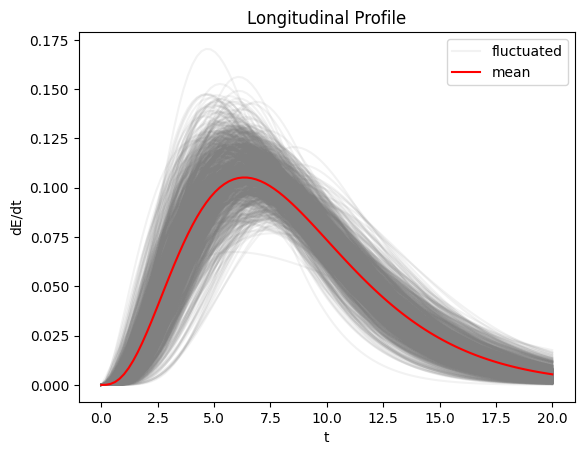

In [6]:
samples = 1000

from calo_flash import get_longitudinal_parameters, longitudinal_pdf

t = np.linspace(0, 20, 100)
fig, ax = plt.subplots()
for i in range(samples):
    params = get_longitudinal_parameters(E, Z)
    ax.plot(t, longitudinal_pdf(t, params['alpha'], params['beta']), 
            color='grey', alpha=0.1,
            label='fluctuated' if i == 0 else None)
ax.plot(t, longitudinal_pdf(t, params['mean_alpha'], params['mean_beta']), 
        label='mean', color='red')
ax.legend()
ax.set_xlabel('t')
ax.set_ylabel('dE/dt')
ax.set_title('Longitudinal Profile')
plt.show()

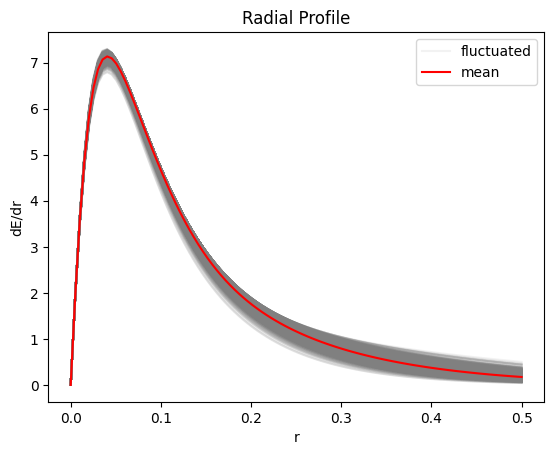

In [7]:
from calo_flash import get_tau, get_radial_parameters, radial_pdf

r = np.linspace(0, 0.5, 100)
fig, ax = plt.subplots()
for i in range(samples):
    long_params = get_longitudinal_parameters(E, Z)
    tau = get_tau(t, long_params['T'], long_params['alpha'], long_params['mean_ln_alpha'])
    R_C, R_T, p = get_radial_parameters(tau, E, Z)
    ax.plot(r, radial_pdf(r, p, R_C, R_T), 
            color='grey', alpha=0.1,
            label='fluctuated' if i == 0 else None)

### Mean profile
tau = get_tau(t, long_params['mean_T'], fluctuate=False)
R_C, R_T, p = get_radial_parameters(tau, E, Z)
ax.plot(r, radial_pdf(r, p, R_C, R_T), 
        label='mean', color='red')
ax.legend()
ax.set_xlabel('r')
ax.set_ylabel('dE/dr')
ax.set_title('Radial Profile')
plt.show()

In [8]:
import numpy as np
from calorimeter import CaloBlock


calo_cfg = {
    'Z': 82,          # Atomic number
    'width': 10.0,     # [X0]
    'depth': 10.0,    # [X0]
    'N_cells_x': 64,  # also sets N_cells_y
    'N_cells_z': 8,
}

calo = CaloBlock(calo_cfg)

In [9]:
from calorimeter import EventGenerator

gen_cfg = {
    'x_range': (-calo_cfg['width']*0.8/2, calo_cfg['width']*0.8/2),
    'y_range': (-calo_cfg['width']*0.8/2, calo_cfg['width']*0.8/2),
    'E_range': (1000, 100_000),  # MeV
    'N_range': (1, 32),  # Number of particles to generate
}

event_gen = EventGenerator(gen_cfg)

In [10]:
event = event_gen.generate()
calo.simulate(*event)

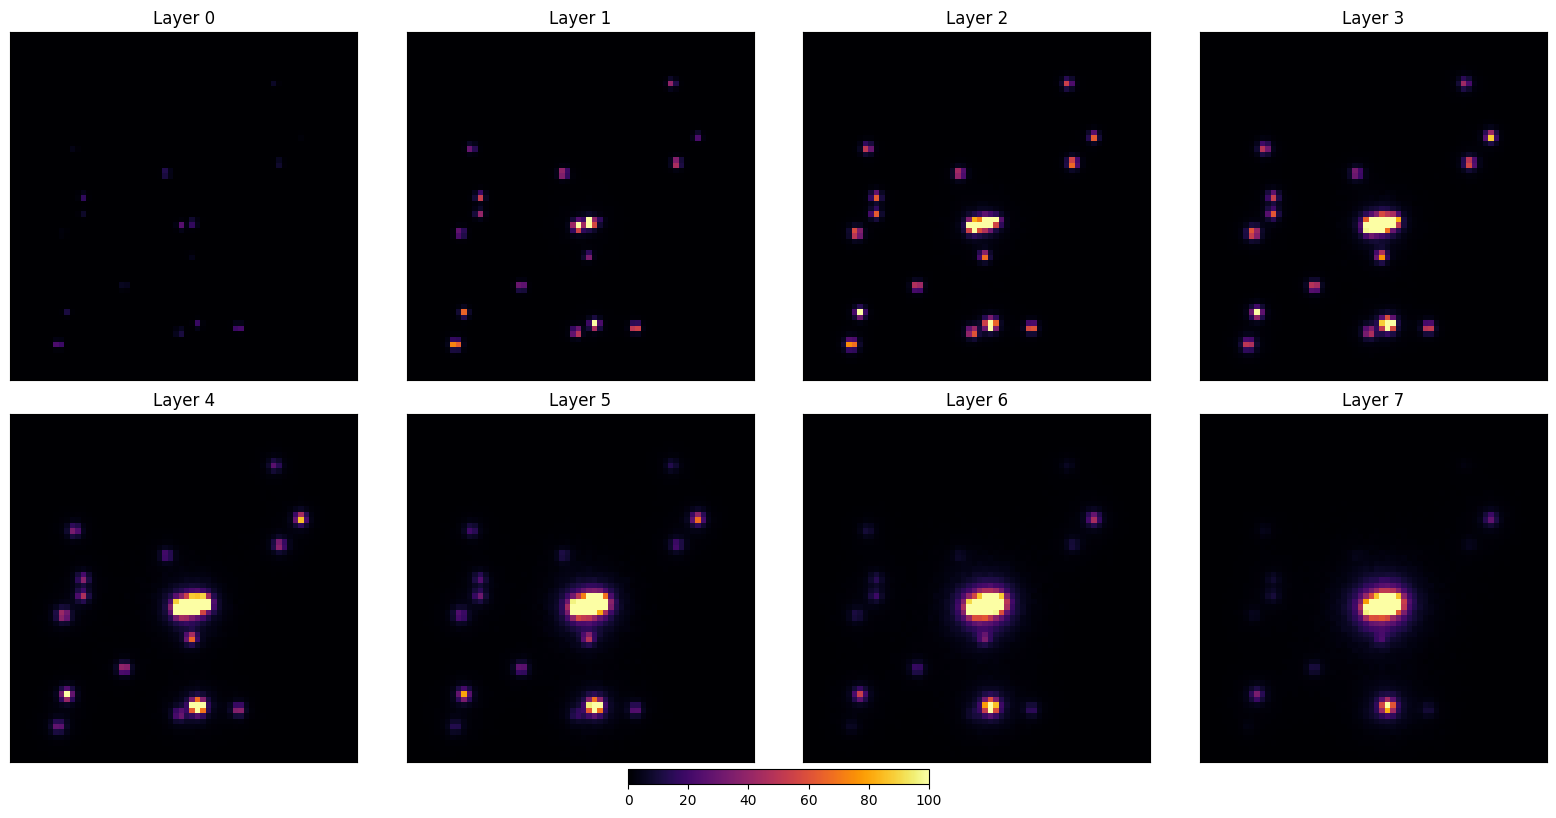

In [11]:
### Plot all 15 layers of the calorimeter with gridspec and imshow
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 20))
gs = gridspec.GridSpec(4, 4, wspace=0.1, hspace=0.1)
vmin, vmax = 0, 100.0
for i in range(calo.N_cells_z):
    ax = fig.add_subplot(gs[i])
    im = ax.imshow(calo.cell_e[:, :, i].T, origin='lower', cmap='inferno', interpolation='nearest',
                   vmin=vmin, vmax=vmax)
    ax.set_title(f'Layer {i}')
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=fig.get_axes(), orientation='horizontal', fraction=0.02, pad=0.01)
plt.show()


In [12]:
import time, tqdm

for label, kwargs in [
    ('with truth ', dict(N_spots_per_layer=1000, store_truth=True)),
    ('no truth   ', dict(N_spots_per_layer=1000, store_truth=False)),
]:
    times = []
    for _ in tqdm.tqdm(range(100), desc=label):
        event = event_gen.generate()
        t0 = time.perf_counter()
        calo.simulate(*event, **kwargs)
        times.append(time.perf_counter() - t0)
    print(f'{label}: {np.mean(times)*1e3:.2f} ± {np.std(times)*1e3:.2f} ms/event')


with truth : 100%|██████████| 100/100 [00:01<00:00, 75.10it/s]


with truth : 13.20 ± 7.75 ms/event


no truth   : 100%|██████████| 100/100 [00:00<00:00, 102.80it/s]

no truth   : 9.64 ± 5.02 ms/event


In [13]:
import cProfile, pstats, io

pr = cProfile.Profile()
pr.enable()
for _ in range(20):
    event = event_gen.generate()
    calo.simulate(*event, N_spots_per_layer=1000, store_truth=False)
pr.disable()

s = io.StringIO()
ps = pstats.Stats(pr, stream=s).sort_stats('tottime')
ps.print_stats(12)
print(s.getvalue())


         6336 function calls (6334 primitive calls) in 0.194 seconds

   Ordered by: internal time
   List reduced from 172 to 12 due to restriction <12>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       20    0.107    0.005    0.171    0.009 /Users/ets/Weizmann Institute Dropbox/Etienne Dreyer/WIS/SimplePflow/calo_flash/calorimeter.py:48(simulate)
       20    0.040    0.002    0.040    0.002 /Users/ets/Weizmann Institute Dropbox/Etienne Dreyer/WIS/SimplePflow/calo_flash/calo_flash.py:187(sample_radii)
       20    0.016    0.001    0.065    0.003 /Users/ets/Weizmann Institute Dropbox/Etienne Dreyer/WIS/SimplePflow/calo_flash/calo_flash.py:237(shoot)
        3    0.007    0.002    0.120    0.040 /Users/ets/miniconda3/envs/torchmetal/lib/python3.12/selectors.py:558(select)
      218    0.004    0.000    0.004    0.000 {method 'ravel' of 'numpy.ndarray' objects}
       60    0.004    0.000    0.004    0.000 {method 'astype' of 'numpy.ndarray' objects}
     